# Neural Network Model

## Goal

Evaluate NN learning models for privacy sensitive prompt detection.

Labels:
- 0 = safe (no PII)
- 1 = privacy sensitive (contains PII)

In [1]:
import random
import numpy as np
import pandas as pd
import torch

In [2]:
SEED = 42

# Python's built-in RNG
random.seed(SEED)               

# NumPy's RNG (Global state for compatibility, or use default_rng)
np.random.seed(SEED)            

# PyTorch CPU RNG
torch.manual_seed(SEED)         

# All CUDA devices (Safe for your 4070 Ti, even if you add more GPUs later)
torch.cuda.manual_seed_all(SEED) 


## Step 1: Trust and Verify Loaded Frozen Data Splits 
Train, validation, and test sets generated by data_split.py.

In [3]:
train = pd.read_parquet('../../data_splits/train.parquet')
val = pd.read_parquet('../../data_splits/val.parquet')
test = pd.read_parquet('../../data_splits/test.parquet')

# Confirm dataset train / val / test breakdowns
summary = pd.DataFrame({
    name: {
        "rows":       len(df),
        "pct_sensitive": df["label"].mean(),                 # fraction of sensitive
        "n_blank":    df["text"].isna().sum() + (df["text"].str.strip() == "").sum(),
    }
    for name, df in [("train", train), ("val", val), ("test", test)]
}).T
print(summary)          # last line → renders as a neat 3×3 table

### CATCHES DATA CHANGES FROM OUR W1 BUILD NO FUNNY BUSINESS!!!!!
assert train.shape[0] == 260338  
assert val.shape[0] == 32542
assert test.shape[0] == 32543
###############################################
# NOTE: the raw-TF-IDF `features = 100000` cap is retired — STEP 2 now loads the pre-built
# 50,018-dim COMBINED matrix, so the feature dimension comes from the matrix, not this constant.
threshold  = 0.5
hidden_dim = 256

           rows  pct_sensitive  n_blank
train  260338.0       0.673770      0.0
val     32542.0       0.673775      0.0
test    32543.0       0.673755      0.0


## STEP 2: Onboard the engineered COMBINED feature set (from `03_feature_engineering`)

The MLP previously trained on **raw TF-IDF (100k) only**. It now consumes the **combined feature set** that
`03_feature_engineering` built and saved to `../feature_matrices/`, so every model in the project trains on **one
identical feature space** (important for a fair MLP-vs-LR-vs-SVM comparison):

| Block | Source | Cols |
|---|---|---|
| TF-IDF (lowercase, uni+bigram, `min_df=2`) | `tfidf_vectorizer.joblib` | 50,000 |
| Basic text-shape features | `src/features/text_features.py` → `extract_text_features` | 10 |
| Privacy-pattern flags | `src/features/pattern_features.py` → `extract_pattern_features` | 8 |
| **COMBINED** (dense blocks MinMax-scaled, fit on train, then `hstack`-ed) | `X_*_combined.npz` | **50,018** |

We **load the saved `.npz` matrices** (fast, and guarantees the exact same vocab/scaling as everyone else). If a
teammate hasn't run `03` locally (the `feature_matrices/` folder is git-ignored), the cell **rebuilds** the same
combined matrix from the repo feature functions. Either way `input_dim` is derived from the matrix width — no longer
hardcoded.

In [4]:
# ============================================================================
# Onboard COMBINED features from 03_feature_engineering.
#   Combined = TF-IDF(50k, uni+bigram)  (+)  10 text-shape feats  (+)  8 pattern flags  = 50,018 cols
#   Primary path: load the .npz matrices 03 saved to ../feature_matrices/ (shared, exact).
#   Fallback:     rebuild from src.features if that folder isn't present locally.
# ============================================================================
from pathlib import Path
from scipy.sparse import load_npz

FEATURE_DIR = Path("../feature_matrices")          # 03_feature_engineering writes here

if (FEATURE_DIR / "X_train_combined.npz").exists():
    print("Loading pre-built COMBINED features from", FEATURE_DIR.resolve())
    X_train = load_npz(str(FEATURE_DIR / "X_train_combined.npz"))
    X_val   = load_npz(str(FEATURE_DIR / "X_val_combined.npz"))
    X_test  = load_npz(str(FEATURE_DIR / "X_test_combined.npz"))
    y_train = np.load(FEATURE_DIR / "y_train.npy")
    y_val   = np.load(FEATURE_DIR / "y_val.npy")
    y_test  = np.load(FEATURE_DIR / "y_test.npy")
else:
    # ---- fallback: rebuild the SAME combined matrix from the repo functions ----
    print("feature_matrices/ not found -> rebuilding COMBINED features from src.features ...")
    import sys; sys.path.insert(0, "../..")         # repo root -> makes `src` importable
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import MinMaxScaler
    from scipy.sparse import csr_matrix, hstack
    from src.features import extract_text_features, extract_pattern_features

    tr, va, te = train["text"].fillna(""), val["text"].fillna(""), test["text"].fillna("")
    vec = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=50000)  # 03 config
    Xt, Xv, Xs = vec.fit_transform(tr), vec.transform(va), vec.transform(te)                 # fit on TRAIN only

    tscl = MinMaxScaler().fit(extract_text_features(tr))       # scalers fit on TRAIN only
    pscl = MinMaxScaler().fit(extract_pattern_features(tr))
    def _txt(s): return csr_matrix(tscl.transform(extract_text_features(s)))
    def _pat(s): return csr_matrix(pscl.transform(extract_pattern_features(s)))

    X_train = hstack([Xt, _txt(tr), _pat(tr)]).tocsr()
    X_val   = hstack([Xv, _txt(va), _pat(va)]).tocsr()
    X_test  = hstack([Xs, _txt(te), _pat(te)]).tocsr()
    y_train, y_val, y_test = train["label"].values, val["label"].values, test["label"].values

# input_dim is now DYNAMIC, driven by the combined matrix (was hardcoded `input_dim = features`)
input_dim = X_train.shape[1]
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "feature-width mismatch across splits!"
assert X_train.shape[0] == len(y_train) == train.shape[0], "X/y row mismatch — did the split change?"
print(f"combined matrices  ->  train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print(f"input_dim = {input_dim:,}   (50,000 TF-IDF + 10 text + 8 pattern)")

Loading pre-built COMBINED features from /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison/notebooks/feature_matrices
combined matrices  ->  train (260338, 50018) | val (32542, 50018) | test (32543, 50018)
input_dim = 50,018   (50,000 TF-IDF + 10 text + 8 pattern)


## STEP 3: PyTorch Data
- Tensor
- Dataset
- Dataloader

DataLoader — wraps a Dataset and processes data in batches, optionally shuffled. 
- Why: **Three reasons**: 
   - (1) memory — you can't hold 104 GB dense, but 256 rows densified is ~25 MB; 
   - (2) learning — gradient descent updates on mini-batches; 
   - (3) GPU throughput — GPUs love crunching a batch in parallel.

### ⚠️ DO NOT RUN THIS on your real X_train — it will try to allocate 104 GB and kill your kernel.
X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)   # (260413, 100000) materialized → boom   

In [5]:
from torch.utils.data import Dataset, DataLoader

class TfidfDataset(Dataset):
    def __init__(self, X_sparse, y):
        """
        X_sparse: A SciPy sparse matrix (e.g., csr_matrix) from TfidfVectorizer
        y: A NumPy array, Pandas Series, or list of targets/labels
        """
        # Ensure the matrix is in Compressed Sparse Row (CSR) format for fast row slicing
        self.X_sparse = X_sparse.tocsr()
        
        # Convert labels to a PyTorch tensor (use torch.float32 for regression/binary, long for multi-class)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        # 1. Slice a single row out of the sparse matrix
        row_sparse = self.X_sparse[idx]
        
        # 2. ⚠️ Convert ONLY this single row to a dense NumPy array, then to a PyTorch float tensor
        row_dense = torch.tensor(row_sparse.toarray()[0], dtype=torch.float32)
        
        # 3. Retrieve the target label
        label = self.y[idx]
        
        return row_dense, label
    
## 4 Threated DataLoaded To Use The GPU more    
train_loader = DataLoader(TfidfDataset(X_train, y_train), batch_size=hidden_dim, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(TfidfDataset(X_val, y_val),     batch_size=hidden_dim, shuffle=False,
                          num_workers=4, pin_memory=True)

for batch_X, batch_y in train_loader:
    print(batch_X.shape, batch_y.shape)
    break

torch.Size([256, 50018]) torch.Size([256])


## STEP 4: BEAT Logistic Regression By Adding a hidden layer and non-linearity
```Alan Logistic Regression:   [100k features] ───────────────► [1 logit] → sigmoid```
```
Fil MLP:              [100k features] → Linear → ReLU → [1 logit] → sigmoid
                                          └── the hidden layer ──┘
```                                          
> ### 🧠 Why the non-linearity is *the whole point*
>
> We add exactly **two** things to logistic regression: a **hidden layer** and a **non-linearity**. 
> If you stack two `Linear` layers with **nothing** between them, the math *collapses*:
> $$W_2(W_1 x + b_1) + b_2 = (W_2 W_1)\,x + (W_2 b_1 + b_2) = \text{a single linear layer}$$
> So two `Linear` layers back-to-back are algebraically identical to **one** linear layer — i.e. **logistic regression with extra steps.**
>
> The **ReLU** (`max(0, x)`) between them breaks that collapse. It lets the network bend its decision boundary and learn **feature interactions** — e.g. *"token A **and** token B together signal PII"* — which a purely linear model fundamentally cannot represent.

> Without the ReLU in the middle out models fc1 in_feat = 1000000 out=256 and fc2 in_feat = 256 out_feat = 1 would collapse to 1000000x1 == logistic regression

In [6]:
import torch.nn as nn
# MLP (Multilayer Perceptron) Class
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, p_drop=0.3):
        super().__init__()                      # MUST be first
      
        self.fc1 = nn.Linear(input_dim , hidden_dim ) # input → hidden

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p_drop) 
        self.fc2 = nn.Linear(hidden_dim, 1)  #  hidden → 1 logit

    def forward(self, x):
        x = x.squeeze(1)  # Cleans shape from (batch_size, 1, 100000) to (batch_size, 100000)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out) # Outputs shape: (batch_size, 1)
        return out
    
model = MLP(input_dim=input_dim, hidden_dim=hidden_dim)
print(model)                       # prints your architecture
xb, yb = next(iter(train_loader))
print(model(xb).shape)  

MLP(
  (fc1): Linear(in_features=50018, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)
torch.Size([256, 1])


## STEP 5: Setup Loss, Optimizer and prep for training loop GPU RECOMMENDED

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, p_drop=0.3).to(device)   # USE THE GPU
criterion = nn.BCEWithLogitsLoss() # Takes raw logits and applies sigmoid + binary cross-entropy

optimizer = torch.optim.AdamW(model.parameters(), 1e-3, weight_decay=1e-2) #gradient-descent engine


In [8]:
from sklearn.metrics import f1_score, recall_score
import torch

EPOCHS, PATIENCE, CKPT = 15, 3, "best_mlp.pt"   # EPOCHS is just an upper bound
best_metric, since_improve = -1.0, 0             # F1 is MAXIMIZED, so start low (not +inf)

def evaluate(model, loader, threshold=threshold):
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits_all.append(model(xb).squeeze(1).cpu())
            labels_all.append(yb)
    logits = torch.cat(logits_all)
    y_true = torch.cat(labels_all).numpy()
    y_pred = (torch.sigmoid(logits) >= threshold).int().numpy()
    return y_true, y_pred

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)     # move batch to device
        logits = model(xb).squeeze(1)             # forward → (batch,)
        loss   = criterion(logits, yb)

        optimizer.zero_grad()                     # clear old gradients
        loss.backward()                           # backprop
        optimizer.step()                          # update weights

        running_loss += loss.item()               # .item() to avoid memory ballooning

    avg_loss = running_loss / len(train_loader)

    # ---- validate ----
    yv, pv = evaluate(model, val_loader)          # re-evaluate current weights
    val_metric = f1_score(yv, pv, pos_label=1)
    print(f"Epoch {epoch+1:02d} | train_loss {avg_loss:.4f} | val_F1 {val_metric:.3f}")

    # ---- early-stopping bookkeeping if three consecutive epochs are not decreasing avg loss then stop early ----
    if val_metric > best_metric:
        best_metric, since_improve = val_metric, 0
        torch.save(model.state_dict(), CKPT)      # checkpoint the BEST weights
        print("   ↳ new best, saved")
    else:
        since_improve += 1
        print(f"   (no improve {since_improve}/{PATIENCE})")
        if since_improve >= PATIENCE:
            print(f"Early stop @ epoch {epoch+1}. Best val_F1 {best_metric:.3f}")
            break

# ---- restore the BEST model, not the degraded final one ----
state_dict = torch.load(CKPT, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)

print(f"Restored best checkpoint (val_F1 {best_metric:.3f})")

Epoch 01 | train_loss 0.4328 | val_F1 0.867
   ↳ new best, saved
Epoch 02 | train_loss 0.3193 | val_F1 0.872
   ↳ new best, saved
Epoch 03 | train_loss 0.2528 | val_F1 0.872
   ↳ new best, saved
Epoch 04 | train_loss 0.1850 | val_F1 0.875
   ↳ new best, saved
Epoch 05 | train_loss 0.1193 | val_F1 0.872
   (no improve 1/3)
Epoch 06 | train_loss 0.0678 | val_F1 0.873
   (no improve 2/3)
Epoch 07 | train_loss 0.0363 | val_F1 0.871
   (no improve 3/3)
Early stop @ epoch 7. Best val_F1 0.875
Restored best checkpoint (val_F1 0.875)


## STEP 6: Validation, metrics & the threshold
### Precision vs Recall Analysis
> Graph the Precision vs Recall to find the optimal threshold we want to identify PII
> - Recall — Of every prompt that truly contained PII, what fraction did the model flag? → TP / (TP + FN)
> - Precision - Of every prompt the model flagged as PII, what fraction actually were? → TP / (TP + FP) 
> - F1 — one number that says "good at both" The harmonic mean of precision and recall: 2·P·R / (P + R) 
>

              precision    recall  f1-score   support

        Safe      0.750     0.716     0.733     10616
         PII      0.865     0.884     0.875     21926

    accuracy                          0.829     32542
   macro avg      0.808     0.800     0.804     32542
weighted avg      0.828     0.829     0.828     32542

[[ 7600  3016]
 [ 2534 19392]]
max-F1 threshold: 0.40   |   ≥95%-recall threshold: 0.20


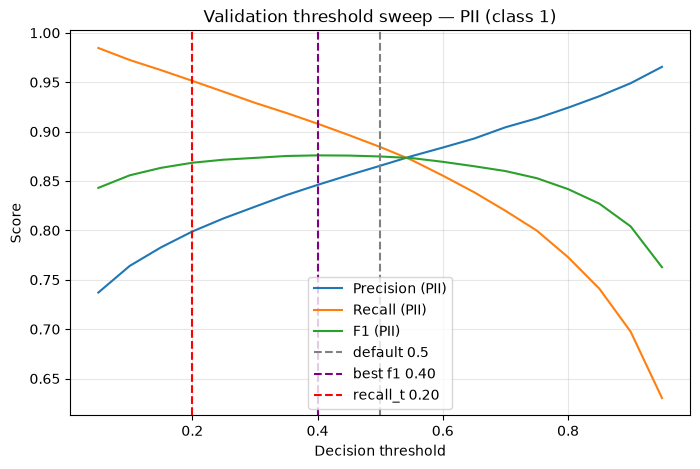

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Don't need multiple workers on eval keeps from throwing errors
val_loader  = DataLoader(TfidfDataset(X_val,  y_val),  batch_size=hidden_dim, shuffle=False, num_workers=0)
test_loader = DataLoader(TfidfDataset(X_test, y_test), batch_size=hidden_dim, shuffle=False, num_workers=0)

## Evaluation for 0.5 Threshold To Compare to Classical Models
yv, pv = evaluate(model, val_loader, 0.5)
print(classification_report(yv, pv, target_names=["Safe","PII"], digits=3))
print(confusion_matrix(yv, pv))

# val probabilities, ONE forward pass (reused for all thresholds)
def get_probs(model, loader):
    model.eval()
    logits, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits.append(model(xb.to(device)).squeeze(1).cpu())
            labels.append(yb)
    return torch.cat(labels).numpy(), torch.sigmoid(torch.cat(logits)).numpy()

y_true, probs = get_probs(model, val_loader)


# sweep a grid from .05 -> .95 every 0.5 save them for the graph and analysis
thresholds = np.arange(0.05, 0.96, 0.05)
prec, rec, f1s, missed = [], [], [], []
for t in thresholds:
    y_pred = (probs >= t).astype(int)
    prec.append(precision_score(y_true, y_pred, pos_label=1, zero_division=0))      
    rec.append(  recall_score(y_true, y_pred, pos_label=1) )     
    f1s.append(  f1_score(y_true, y_pred, pos_label=1))   
    missed.append(((y_true == 1) & (y_pred == 0)).sum())   # false negatives = PII let through

### Find the best f1 and optimal recal threshold for given TARGET
best_f1_t = thresholds[np.argmax(f1s)]                       
# security-oriented: highest threshold that still hits a recall floor (keeps precision as high as possible)
TARGET = 0.95
ok = [t for t, r in zip(thresholds, rec) if r >= TARGET]
recall_t = max(ok) if ok else thresholds[0]
print(f"max-F1 threshold: {best_f1_t:.2f}   |   ≥{TARGET:.0%}-recall threshold: {recall_t:.2f}")

# 3) plot
plt.figure(figsize=(8,5))
plt.plot(thresholds, prec, label="Precision (PII)")
plt.plot(thresholds, rec,  label="Recall (PII)")
plt.plot(thresholds, f1s,  label="F1 (PII)")
plt.axvline(0.5, ls="--", color="gray", label="default 0.5")
plt.axvline(best_f1_t, ls="--", color="purple", label=f"best f1 {best_f1_t:.2f}")
plt.axvline(recall_t, ls="--", color="red", label=f"recall_t {recall_t:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title("Validation threshold sweep — PII (class 1)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# STEP 7: THE TRUTH RUN THIS ONLY ONCE
## Final test evaluation 

In [10]:
# from sklearn.metrics import classification_report, confusion_matrix
# from torch.utils.data import DataLoader

# # single pass → no workers, no shuffle
# test_loader = DataLoader(TfidfDataset(X_test, y_test), batch_size=256, shuffle=False, num_workers=0)

# # `model` must be your RESTORED best checkpoint — do NOT retrain after this
# yt, pt = evaluate(model, test_loader)        # default 0.5 → apples-to-apples with LR
# print(classification_report(yt, pt, target_names=["Safe","PII"], digits=3))
# print(confusion_matrix(yt, pt))

> ⚠️ **The report below is from the OLD raw-TF-IDF (100k) run.** After onboarding the combined features (STEP 2),
> re-run the notebook so this regenerates. Baseline to beat (val, threshold 0.5):
> **PII F1 0.847 · PII recall 0.848 · FN 3,331 · FPR 0.319.** Goal: fewer false alarms (lower FPR) at
> equal-or-better PII recall — the pattern/shape features add the explicit identifier signal TF-IDF only approximates.

             precision    recall  f1-score   support

        Safe      0.685     0.681     0.683     10626
         PII      0.846     0.848     0.847     21926

    accuracy                          0.793     32552
   macro avg      0.765     0.764     0.765     32552
weighted avg      0.793     0.793     0.793     32552

[[ 7235  3391]
 [ 3331 18595]]

## STEP 8: ERROR ANALYSIS
PII the model called Safe  ← the dangerous misses
Safe the model flagged as PII

Look it over with your eyes

In [11]:
yv, pv = evaluate(model, val_loader)          # val_loader shuffle=False → rows stay aligned
res = val.copy()
res["true"], res["pred"] = yv, pv

fn  = res[(res.true == 1) & (res.pred == 0)]   # missed PII  → the dangerous errors
fp  = res[(res.true == 0) & (res.pred == 1)]   # false alarms
pii = res[res.true == 1]                        # all true PII (the baseline to compare to)
print(f"FN (missed PII): {len(fn)}    FP (false alarms): {len(fp)}\n")

def rate(s, pat): return s.str.contains(pat, regex=True, na=False).mean()

print("Median length   — all PII: {:.0f}   | missed: {:.0f}".format(
      pii.text.str.len().median(), fn.text.str.len().median()))
print("Has HTML tag     — all PII: {:.1%} | missed: {:.1%}".format(
      rate(pii.text, r"<[^>]+>"), rate(fn.text, r"<[^>]+>")))
print("Has [PLACEHOLDER]— all PII: {:.1%} | missed: {:.1%}".format(
      rate(pii.text, r"\[[A-Z_]+\d*\]"), rate(fn.text, r"\[[A-Z_]+\d*\]")))

print("\n--- 8 missed-PII examples ---")
for t in fn.text.head(8):
    print(repr(t[:160]))

FN (missed PII): 2534    FP (false alarms): 3016

Median length   — all PII: 146   | missed: 124
Has HTML tag     — all PII: 26.2% | missed: 16.2%
Has [PLACEHOLDER]— all PII: 1.6% | missed: 2.0%

--- 8 missed-PII examples ---
"Allô alev.molinario, est-ce que tu connais une bonne ressource pour réviser mes leçons d'informatique ? J'ai un exam."
'Kun je jouw coordinate ([51.7, 4.7]) voor ons nieuwe project noteren en 33A bijwerken?'
'Eine umfassende Bewertung der Mental Health Needs Assessment erfordert die Speicherung von Fahrzeuginformationen mittels VIN-Nummer HNN5JFZX1YVDMT8FP und die Nu'
'Transferts suspects observés sur 18:11:a5:c9:79:e4. Le montant contesté est de 267314.27. Consultez immédiatement les canaux http://www.monnet.ch/ et Les Goutte'
"Hallo Bleonit, wie geht's? Ich bin besorgt über meinen Männlich-DE nach der Schule. Er verbringt viel Zeit online um  09:41 Uhr? Hat jemand Tipps?, um das Wohlb"
'Bonjour à tous, nous cherchons des volontaires pour distribuer des brochure

### Conclusion — MLP vs Logistic Regression (Based on Alan's Results) (validation, threshold 0.5)
| | LR | MLP |
|---|---|---|
| PII F1 | 0.85 | 0.855 |
| **PII recall** | **0.886** | 0.852 |
| PII false negatives | **2,500** | 3,002 |
| Macro-F1 | 0.74 | 0.772 |

On **identical TF-IDF features**, adding a hidden layer + non-linearity **did not improve
PII detection.** The MLP ties LR on F1 and is better balanced, but has **lower recall** —
the metric that matters most for a DLP screen (a false negative = leaked PII). The MLP also
**overfit quickly** (train loss → 0.02, val plateaued ~0.855), so its extra capacity went to
memorization, not generalization. **The bottleneck is the feature representation, not the model.**

### Limitations & future work
- Bag-of-words can't generalize PII *patterns* → **char n-grams**, **regex pattern features**,
  or **contextual embeddings (DistilBERT)** are the paths beyond ~0.85.
- TF-IDF fragments the **multilingual** vocabulary.
- Minor data caveats: a few duplicate texts leak across split boundaries; ~6 blank rows (all in train).
- **Threshold** is a deployment lever: lowering it raises PII recall at precision cost.

Alan and I will still need to compare notes